In [1]:
%matplotlib inline
import sys
sys.path.append('/home/jack/Dev/candles-bot/scripts')

import importlib
import smc_features
importlib.reload(smc_features)
from smc_features import (
    set_dark_theme, build_pipeline,
    align_timeframes
)

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

set_dark_theme()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f"Device  : {device}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Prêt !")

Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
Prêt !


In [2]:
# Charger le dataset sauvegardé
df_ml = pd.read_csv(
    '/home/jack/Dev/candles-bot/data/eurusd_mtf_features.csv',
    index_col=0, parse_dates=True)

print(f"Dataset chargé : {df_ml.shape}")
print(f"Période        : {df_ml.index[0]} → {df_ml.index[-1]}")

# Features numériques uniquement
features = [
    col for col in df_ml.columns
    if col not in ['Label', 'Close']
    and df_ml[col].dtype in ['float64', 'int64', 'int32', 'float32']
]

# Groupes pour vérification
f_1h = [f for f in features if f.endswith('_1H')]
f_4h = [f for f in features if f.endswith('_4H')]
f_1d = [f for f in features if f.endswith('_1D')]

print(f"\nFeatures 1H : {len(f_1h)}")
print(f"Features 4H : {len(f_4h)}")
print(f"Features 1D : {len(f_1d)}")
print(f"Total       : {len(features)}")

hausse = df_ml['Label'].sum()
total  = len(df_ml)
print(f"\nLabel hausse : {hausse} ({hausse/total*100:.1f}%)")
print(f"Label baisse : {total-hausse} ({(total-hausse)/total*100:.1f}%)")

Dataset chargé : (10965, 116)
Période        : 2023-07-28 07:00:00+00:00 → 2026-04-24 20:00:00+00:00

Features 1H : 38
Features 4H : 38
Features 1D : 38
Total       : 114

Label hausse : 1129 (10.3%)
Label baisse : 9836 (89.7%)


In [3]:
SEQ_LEN = 60  # 60 bougies 1H = 2.5 jours de contexte

# Séparation train/test chronologique
split   = int(len(df_ml) * 0.8)
df_train= df_ml.iloc[:split]
df_test = df_ml.iloc[split:]

print(f"Train : {len(df_train)} bougies "
      f"({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Test  : {len(df_test)} bougies "
      f"({df_test.index[0].date()} → {df_test.index[-1].date()})")

# Normalisation — RobustScaler sur train uniquement
scaler   = RobustScaler()
X_train_scaled = scaler.fit_transform(df_train[features])
X_test_scaled  = scaler.transform(df_test[features])
y_train_raw    = df_train['Label'].values
y_test_raw     = df_test['Label'].values

# Créer les séquences
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_raw, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(
    X_test_scaled,  y_test_raw,  SEQ_LEN)

# Convertir en tenseurs
X_train = torch.FloatTensor(X_train_seq).to(device)
X_test  = torch.FloatTensor(X_test_seq).to(device)
y_train = torch.FloatTensor(y_train_seq).to(device)
y_test  = torch.FloatTensor(y_test_seq).to(device)

dates_test = df_test.index[SEQ_LEN:]

print(f"\nShapes tenseurs :")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Features: {len(features)}")
print(f"\nChaque séquence = {SEQ_LEN}h × {len(features)} features")
print(f"= {SEQ_LEN * len(features)} valeurs par entrée")

Train : 8772 bougies (2023-07-28 → 2025-10-10)
Test  : 2193 bougies (2025-10-10 → 2026-04-24)

Shapes tenseurs :
  X_train : torch.Size([8712, 60, 114])
  X_test  : torch.Size([2133, 60, 114])
  Features: 114

Chaque séquence = 60h × 114 features
= 6840 valeurs par entrée


In [4]:
class AttentionLayer(nn.Module):
    """
    Couche Attention — apprend à pondérer
    les timesteps importants dans la séquence
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, lstm_output):
        # lstm_output : (batch, seq_len, hidden)
        scores  = self.attention(lstm_output)  # (batch, seq, 1)
        weights = torch.softmax(scores, dim=1) # (batch, seq, 1)
        context = (weights * lstm_output).sum(dim=1)  # (batch, hidden)
        return context, weights


class LSTMTraderMTF(nn.Module):
    """
    LSTM Multi-Timeframe avec Attention.

    Architecture :
    Input (batch, 60, n_features)
        → LSTM 1 (128 unités) — patterns courts 1-5h
        → LSTM 2 (64 unités)  — patterns moyens 5-24h
        → Attention            — focus sur timesteps clés
        → Dense 64 → 32 → 1
        → Sigmoid              — probabilité hausse
    """
    def __init__(self, input_size, hidden1=128,
                 hidden2=64, dropout=0.3):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden1,
            num_layers   = 1,
            batch_first  = True,
            dropout      = 0
        )
        self.lstm2 = nn.LSTM(
            input_size   = hidden1,
            hidden_size  = hidden2,
            num_layers   = 1,
            batch_first  = True,
            dropout      = 0
        )

        self.attention = AttentionLayer(hidden2)
        self.norm1     = nn.LayerNorm(hidden1)
        self.norm2     = nn.LayerNorm(hidden2)
        self.dropout   = nn.Dropout(dropout)

        self.fc1       = nn.Linear(hidden2, 32)
        self.fc2       = nn.Linear(32, 1)
        self.relu      = nn.ReLU()
        self.sigmoid   = nn.Sigmoid()

    def forward(self, x, return_attention=False):
        # LSTM 1
        out1, _ = self.lstm1(x)
        out1    = self.norm1(out1)
        out1    = self.dropout(out1)

        # LSTM 2
        out2, _ = self.lstm2(out1)
        out2    = self.norm2(out2)
        out2    = self.dropout(out2)

        # Attention
        context, weights = self.attention(out2)

        # Décision
        out = self.relu(self.fc1(context))
        out = self.dropout(out)
        out = self.sigmoid(self.fc2(out))

        if return_attention:
            return out.squeeze(), weights
        return out.squeeze()


# Instancier
model = LSTMTraderMTF(
    input_size = len(features),
    hidden1    = 128,
    hidden2    = 64,
    dropout    = 0.25
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print("Architecture LSTM MTF + Attention :")
print(f"  Input     : {len(features)} features × {SEQ_LEN} timesteps")
print(f"  LSTM 1    : 128 unités")
print(f"  LSTM 2    : 64 unités")
print(f"  Attention : focus sur timesteps clés")
print(f"  Dense     : 64 → 32 → 1")
print(f"  Paramètres: {total_params:,}")
print(f"  Device    : {next(model.parameters()).device}")

Architecture LSTM MTF + Attention :
  Input     : 114 features × 60 timesteps
  LSTM 1    : 128 unités
  LSTM 2    : 64 unités
  Attention : focus sur timesteps clés
  Dense     : 64 → 32 → 1
  Paramètres: 179,202
  Device    : cuda:0


In [5]:
from torch.utils.data import DataLoader, TensorDataset

EPOCHS     = 150
BATCH_SIZE = 64
LR         = 0.0003

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

history    = {'train_loss':[], 'val_loss':[], 'val_acc':[]}
best_acc   = 0
best_model = None
patience   = 25
no_improve = 0

print(f"Entraînement — {EPOCHS} epochs sur {device}")
print(f"Features : {len(features)} | Séquence : {SEQ_LEN}h")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output     = model(X_batch)
        loss       = criterion(output, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    scheduler.step()

    model.eval()
    with torch.no_grad():
        val_output = model(X_test)
        val_loss   = criterion(val_output, y_test).item()
        val_pred   = (val_output > 0.5).float()
        val_acc    = (val_pred == y_test).float().mean().item()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_acc:
        best_acc   = val_acc
        best_model = {k: v.clone()
                      for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 15 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Acc: {val_acc*100:.1f}% | "
              f"Best: {best_acc*100:.1f}%")

    if no_improve >= patience:
        print(f"\nEarly stopping epoch {epoch+1}")
        break

model.load_state_dict(best_model)
print(f"\nMeilleure précision : {best_acc*100:.1f}%")

Entraînement — 150 epochs sur cuda
Features : 114 | Séquence : 60h
------------------------------------------------------------
Epoch  15/150 | Train: 0.3018 | Val: 0.3049 | Acc: 91.0% | Best: 91.0%

Early stopping epoch 26

Meilleure précision : 91.0%


In [6]:
model.eval()
with torch.no_grad():
    probas   = model(X_test).cpu().numpy()
    y_pred   = (probas > 0.5).astype(int)
    y_true   = y_test.cpu().numpy().astype(int)

print("=" * 50)
print("   RÉSULTATS LSTM MTF + ATTENTION")
print("=" * 50)
print(f"\nPrécision globale : {accuracy_score(y_true, y_pred)*100:.1f}%")
print(f"\nRapport détaillé :")
print(classification_report(
    y_true, y_pred,
    target_names=['Baisse (0)', 'Hausse (1)']))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
print(f"Matrice de confusion :")
print(f"  Vrais Baisse : {cm[0,0]:4d} | Faux Hausse : {cm[0,1]:4d}")
print(f"  Faux Baisse  : {cm[1,0]:4d} | Vrais Hausse: {cm[1,1]:4d}")

# Seuils de confiance
print(f"\nAnalyse par seuil de confiance :")
print(f"{'Seuil':>8} {'Signaux':>9} {'%jours':>8} {'Précision':>11}")
print("-" * 42)
for seuil in [0.52, 0.55, 0.58, 0.60, 0.65]:
    mask = probas > seuil
    n    = mask.sum()
    if n > 20:
        acc = accuracy_score(y_true[mask], y_pred[mask])
        print(f"  {seuil:.2f}  {n:8d}  "
              f"{n/len(probas)*100:7.1f}%  "
              f"{acc*100:10.1f}%")
    else:
        print(f"  {seuil:.2f}  {n:8d}  "
              f"{n/len(probas)*100:7.1f}%  "
              f"{'trop peu':>10}")

   RÉSULTATS LSTM MTF + ATTENTION

Précision globale : 91.0%

Rapport détaillé :
              precision    recall  f1-score   support

  Baisse (0)       0.91      1.00      0.95      1942
  Hausse (1)       0.00      0.00      0.00       191

    accuracy                           0.91      2133
   macro avg       0.46      0.50      0.48      2133
weighted avg       0.83      0.91      0.87      2133

Matrice de confusion :
  Vrais Baisse : 1942 | Faux Hausse :    0
  Faux Baisse  :  191 | Vrais Hausse:    0

Analyse par seuil de confiance :
   Seuil   Signaux   %jours   Précision
------------------------------------------
  0.52         0      0.0%    trop peu
  0.55         0      0.0%    trop peu
  0.58         0      0.0%    trop peu
  0.60         0      0.0%    trop peu
  0.65         0      0.0%    trop peu


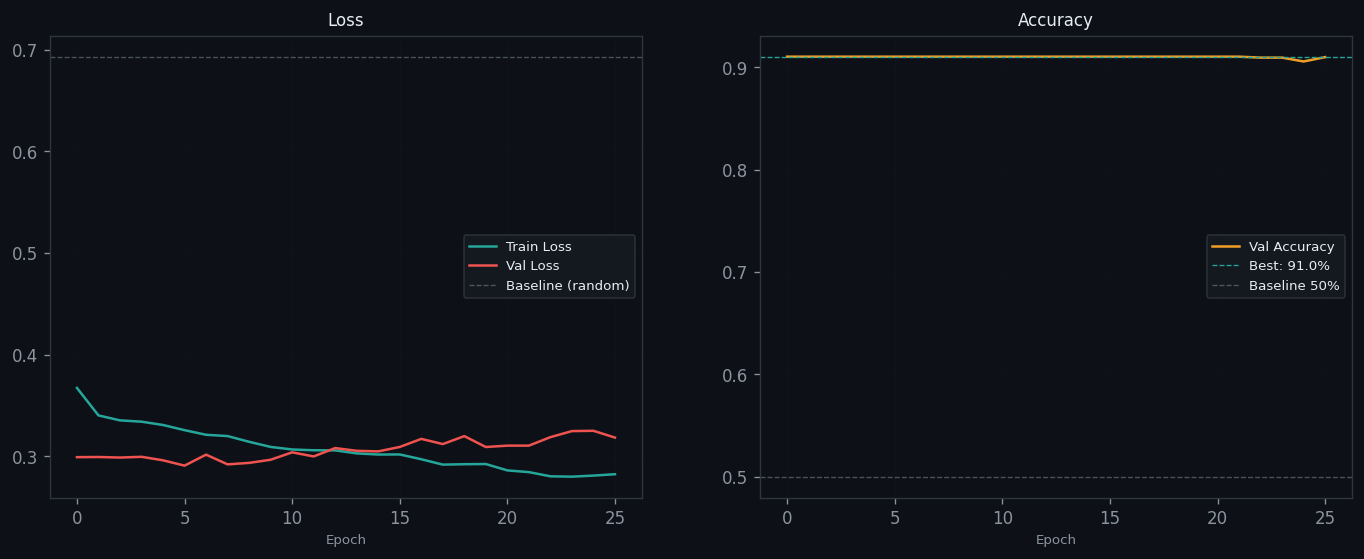

Courbe sauvegardée !


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          facecolor='#0d1117')

for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# Loss
axes[0].plot(history['train_loss'],
             color='#26a69a', linewidth=1.5,
             label='Train Loss')
axes[0].plot(history['val_loss'],
             color='#ef5350', linewidth=1.5,
             label='Val Loss')
axes[0].axhline(0.693, color='#8b949e',
                linewidth=0.8, linestyle='--',
                alpha=0.5, label='Baseline (random)')
axes[0].set_title('Loss', color='#e6edf3', fontsize=10)
axes[0].set_xlabel('Epoch', color='#8b949e', fontsize=8)
axes[0].legend(fontsize=8, facecolor='#161b22',
               edgecolor='#30363d')
axes[0].grid(True, alpha=0.15, color='#21262d')

# Accuracy
axes[1].plot(history['val_acc'],
             color='#EF9F27', linewidth=1.5,
             label='Val Accuracy')
axes[1].axhline(best_acc, color='#26a69a',
                linewidth=0.8, linestyle='--',
                label=f'Best: {best_acc*100:.1f}%')
axes[1].axhline(0.5, color='#8b949e',
                linewidth=0.8, linestyle='--',
                alpha=0.5, label='Baseline 50%')
axes[1].set_title('Accuracy', color='#e6edf3', fontsize=10)
axes[1].set_xlabel('Epoch', color='#8b949e', fontsize=8)
axes[1].legend(fontsize=8, facecolor='#161b22',
               edgecolor='#30363d')
axes[1].grid(True, alpha=0.15, color='#21262d')

plt.savefig(
    '/home/jack/Dev/candles-bot/models/lstm_mtf_training.png',
    bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()
print("Courbe sauvegardée !")


In [8]:
# Diagnostic du seuil
pip = 0.0001
print("Distribution des mouvements 1H :")
for seuil in [3, 5, 7, 10, 15, 20]:
    hausse = ((df_ml['Close'].shift(-1) - df_ml['Close']) > seuil * pip).sum()
    total  = len(df_ml.dropna())
    print(f"  Seuil {seuil:3d} pips : {hausse:5d} hausses "
          f"({hausse/total*100:.1f}%) "
          f"/ {total-hausse:5d} baisses "
          f"({(total-hausse)/total*100:.1f}%)")

Distribution des mouvements 1H :
  Seuil   3 pips :  3401 hausses (31.0%) /  7564 baisses (69.0%)
  Seuil   5 pips :  2435 hausses (22.2%) /  8530 baisses (77.8%)
  Seuil   7 pips :  1744 hausses (15.9%) /  9221 baisses (84.1%)
  Seuil  10 pips :  1129 hausses (10.3%) /  9836 baisses (89.7%)
  Seuil  15 pips :   604 hausses (5.5%) / 10361 baisses (94.5%)
  Seuil  20 pips :   335 hausses (3.1%) / 10630 baisses (96.9%)


In [9]:
# Cellule complète — tout recharger
import sys
sys.path.append('/home/jack/Dev/candles-bot/scripts')
import importlib
import smc_features
importlib.reload(smc_features)
from smc_features import (
    set_dark_theme, build_pipeline, align_timeframes
)

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

set_dark_theme()
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"Device : {device}")

# ── DONNÉES ────────────────────────────────────────────────────
print("\nTéléchargement EUR/USD...")
SYMBOL    = "EURUSD=X"

df_1d_raw = yf.download(SYMBOL, start="2020-01-01",
                         interval='1d', progress=False)
df_1d_raw.columns = [col[0] for col in df_1d_raw.columns]

df_4h_raw = yf.download(SYMBOL, period="729d",
                         interval='4h', progress=False)
df_4h_raw.columns = [col[0] for col in df_4h_raw.columns]

df_1h_raw = yf.download(SYMBOL, period="729d",
                         interval='1h', progress=False)
df_1h_raw.columns = [col[0] for col in df_1h_raw.columns]

print(f"Daily : {len(df_1d_raw)} | "
      f"4H : {len(df_4h_raw)} | "
      f"1H : {len(df_1h_raw)}")

# ── PIPELINES ──────────────────────────────────────────────────
df_1d = build_pipeline(df_1d_raw, '1D')
df_4h = build_pipeline(df_4h_raw, '4H')
df_1h = build_pipeline(df_1h_raw, '1H')

# ── FUSION MTF ─────────────────────────────────────────────────
df_mtf = align_timeframes(df_1d, df_4h, df_1h)
print(f"\nMTF fusionné : {df_mtf.shape}")

# ── LABEL DIRECTION SIMPLE ─────────────────────────────────────
future       = df_mtf['Close'].shift(-1)
df_mtf['Label'] = (future > df_mtf['Close']).astype(int)

features = [
    col for col in df_mtf.columns
    if col not in ['Label','Close']
    and df_mtf[col].dtype in [
        'float64','int64','int32','float32']
]

df_ml = df_mtf[features + ['Label','Close']].dropna()

hausse = df_ml['Label'].sum()
total  = len(df_ml)
print(f"\nLabel direction simple :")
print(f"  Hausse : {hausse} ({hausse/total*100:.1f}%)")
print(f"  Baisse : {total-hausse} "
      f"({(total-hausse)/total*100:.1f}%)")
print(f"  Total  : {total}")
print(f"  Features: {len(features)}")

Device : cuda

Téléchargement EUR/USD...
Daily : 1646 | 4H : 4359 | 1H : 17246

Pipeline 1D...
  Kill Zones   : (1646, 13)
  RSI Ribbon   : (1646, 18)
  SMC Features : (1627, 32)
  ATR + CVD    : (1578, 45)
  Shape final  : (1578, 45)
  Période      : 2020-04-06 → 2026-04-29

Pipeline 4H...
  Kill Zones   : (4359, 13)
  RSI Ribbon   : (4359, 18)
  SMC Features : (4340, 32)
  ATR + CVD    : (4163, 45)
  Shape final  : (4163, 45)
  Période      : 2023-07-31 → 2026-04-29

Pipeline 1H...
  Kill Zones   : (17246, 13)
  RSI Ribbon   : (17246, 18)
  SMC Features : (17227, 32)
  ATR + CVD    : (11110, 45)
  Shape final  : (11110, 45)
  Période      : 2023-07-19 → 2026-04-29
Alignement des timeframes...
Shape fusionné : (10972, 125)
Période        : 2023-08-02 → 2026-04-29

MTF fusionné : (10972, 125)

Label direction simple :
  Hausse : 5019 (45.7%)
  Baisse : 5953 (54.3%)
  Total  : 10972
  Features: 118


In [11]:
# Sélection des features les plus prédictives
# On garde les features SMC + RSI scores + Kill Zones
# et on supprime les features redondantes

features_selected = [
    # RSI Ribbon 3TF — confluence
    'RSI_score_1H', 'RSI_7_1H', 'RSI_14_1H', 'RSI_21_1H',
    'RSI_score_4H', 'RSI_7_4H', 'RSI_14_4H',
    'RSI_score_1D', 'RSI_7_1D', 'RSI_14_1D',

    # SMC 1H — signaux entrée
    'ssl_distance_1H', 'bsl_distance_1H',
    'near_ssl_1H', 'near_bsl_1H',
    'ob_bullish_1H', 'ob_bearish_1H',
    'fvg_bullish_1H', 'fvg_bearish_1H',
    'choch_bullish_1H', 'choch_bearish_1H',
    'liq_sweep_bull_1H', 'liq_sweep_bear_1H',

    # SMC 4H — confirmation
    'ssl_distance_4H', 'bsl_distance_4H',
    'ob_bullish_4H', 'ob_bearish_4H',
    'choch_bullish_4H', 'choch_bearish_4H',
    'liq_sweep_bull_4H', 'liq_sweep_bear_4H',

    # SMC 1D — biais
    'ssl_distance_1D', 'bsl_distance_1D',
    'ob_bullish_1D', 'ob_bearish_1D',
    'choch_bullish_1D', 'liq_sweep_bull_1D',

    # CVD + divergences
    'CVD_norm_1H', 'div_bull_cvd_1H', 'div_bear_cvd_1H',
    'CVD_norm_4H', 'div_bull_cvd_4H', 'div_bear_cvd_4H',
    'CVD_norm_1D', 'div_bull_cvd_1D', 'div_bear_cvd_1D',

    # ATR + volatilité
    'ATR_norm_1H', 'high_vol_1H', 'low_vol_1H',
    'ATR_norm_4H', 'high_vol_4H',
    'ATR_norm_1D', 'high_vol_1D',

    # Kill Zones
    'kz_multiplier_1H', 'in_kill_zone_1H',
    'kz_london_1H', 'kz_ny_1H',
]

# Vérifier que toutes les features existent
features_ok = [f for f in features_selected
               if f in df_ml.columns]
features_missing = [f for f in features_selected
                    if f not in df_ml.columns]

if features_missing:
    print(f"⚠️ Manquantes : {features_missing}")

print(f"Features sélectionnées : {len(features_ok)}")
print(f"  vs avant             : {len(features)} features")
print(f"  Réduction            : "
      f"{len(features)-len(features_ok)} features supprimées")

# Recréer séquences avec features réduites
SEQ_LEN = 60
split   = int(len(df_ml) * 0.8)
df_train= df_ml.iloc[:split]
df_test = df_ml.iloc[split:]

scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(
    df_train[features_ok])
X_test_scaled  = scaler.transform(
    df_test[features_ok])
y_train_raw    = df_train['Label'].values
y_test_raw     = df_test['Label'].values

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_raw, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(
    X_test_scaled,  y_test_raw,  SEQ_LEN)

X_train = torch.FloatTensor(X_train_seq).to(device)
X_test  = torch.FloatTensor(X_test_seq).to(device)
y_train = torch.FloatTensor(y_train_seq).to(device)
y_test  = torch.FloatTensor(y_test_seq).to(device)

n_baisse   = (y_train_seq == 0).sum()
n_hausse   = (y_train_seq == 1).sum()
pos_weight = torch.tensor([n_baisse / n_hausse]).to(device)

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Pos weight : {pos_weight.item():.3f}")

# Modèle plus régularisé
model = LSTMTraderMTF(
    input_size = len(features_ok),
    hidden1    = 64,   # réduit pour éviter overfitting
    hidden2    = 32,
    dropout    = 0.4   # plus de dropout
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres : {total_params:,}")

# Entraînement
EPOCHS     = 200
BATCH_SIZE = 32   # plus petit pour mieux généraliser
LR         = 0.0001

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-7)

history    = {'train_loss':[], 'val_loss':[], 'val_acc':[]}
best_acc   = 0
best_model = None
patience   = 40
no_improve = 0

print(f"\nEntraînement optimisé — {EPOCHS} epochs")
print(f"Features : {len(features_ok)} | "
      f"Batch : {BATCH_SIZE} | LR : {LR}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output     = model(X_batch)
        loss       = criterion(output, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    scheduler.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_test)
        val_loss   = criterion(val_logits, y_test).item()
        val_probas = torch.sigmoid(val_logits)
        val_pred   = (val_probas > 0.5).float()
        val_acc    = (val_pred == y_test).float().mean().item()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_acc:
        best_acc   = val_acc
        best_model = {k: v.clone()
                      for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Acc: {val_acc*100:.1f}% | "
              f"Best: {best_acc*100:.1f}%")

    if no_improve >= patience:
        print(f"\nEarly stopping epoch {epoch+1}")
        break

model.load_state_dict(best_model)
print(f"\nMeilleure précision : {best_acc*100:.1f}%")

# Évaluation
model.eval()
with torch.no_grad():
    val_logits = model(X_test)
    probas     = torch.sigmoid(val_logits).cpu().numpy()
    y_pred     = (probas > 0.5).astype(int)
    y_true     = y_test.cpu().numpy().astype(int)

print("\n" + "=" * 50)
print(classification_report(
    y_true, y_pred,
    target_names=['Baisse (0)', 'Hausse (1)']))

print("Analyse par seuil :")
print(f"{'Seuil':>8} {'N':>8} {'%':>6} {'Précision':>11}")
print("-" * 38)
for seuil in [0.52, 0.55, 0.58, 0.60, 0.65]:
    mask = probas > seuil
    n    = mask.sum()
    if n > 20:
        acc = accuracy_score(
            y_true[mask],
            (probas[mask] > 0.5).astype(int))
        print(f"  {seuil:.2f}  {n:7d}  "
              f"{n/len(probas)*100:5.1f}%  "
              f"{acc*100:10.1f}%")
    else:
        print(f"  {seuil:.2f}  {n:7d}  "
              f"{n/len(probas)*100:5.1f}%  trop peu")

Features sélectionnées : 56
  vs avant             : 118 features
  Réduction            : 62 features supprimées

X_train : torch.Size([8717, 60, 56])
X_test  : torch.Size([2135, 60, 56])
Pos weight : 1.185
Paramètres : 45,602

Entraînement optimisé — 200 epochs
Features : 56 | Batch : 32 | LR : 0.0001
------------------------------------------------------------
Epoch  20/200 | Train: 0.7482 | Val: 0.7584 | Acc: 48.9% | Best: 51.6%
Epoch  40/200 | Train: 0.7458 | Val: 0.7670 | Acc: 49.3% | Best: 51.6%

Early stopping epoch 46

Meilleure précision : 51.6%

              precision    recall  f1-score   support

  Baisse (0)       0.56      0.53      0.54      1159
  Hausse (1)       0.47      0.49      0.48       976

    accuracy                           0.52      2135
   macro avg       0.51      0.51      0.51      2135
weighted avg       0.52      0.52      0.52      2135

Analyse par seuil :
   Seuil        N      %   Précision
--------------------------------------
  0.52      62

In [12]:
# Label intelligent — basé sur confluence SMC
# Signal = 1 uniquement quand conditions optimales réunies

def create_smart_label(df, horizon=3, pip_target=15,
                        pip_stop=10):
    """
    Label 1 si :
    - Prix monte de pip_target dans les horizon prochaines bougies
    - ET ne descend pas de pip_stop avant (stop-loss respecté)

    C'est un label Risk/Reward — plus réaliste pour le trading
    """
    df    = df.copy()
    pip   = 0.0001
    close = df['Close'].values
    n     = len(close)
    label = np.zeros(n, dtype=int)

    for i in range(n - horizon):
        entry    = close[i]
        target   = entry + pip_target * pip
        stop     = entry - pip_stop   * pip
        hit_tp   = False
        hit_sl   = False

        for j in range(i+1, min(i+horizon+1, n)):
            if close[j] >= target:
                hit_tp = True
                break
            if close[j] <= stop:
                hit_sl = True
                break

        label[i] = 1 if hit_tp and not hit_sl else 0

    df['Label'] = label
    return df

# Appliquer
df_smart = create_smart_label(
    df_mtf,
    horizon    = 6,   # 6 heures pour atteindre la cible
    pip_target = 15,  # cible +15 pips
    pip_stop   = 10   # stop -10 pips (RR = 1.5)
)

# Stats
hausse = df_smart['Label'].sum()
total  = len(df_smart)
print(f"Label Smart RR 1.5 :")
print(f"  Signal (1) : {hausse:5d} ({hausse/total*100:.1f}%)")
print(f"  Pas signal : {total-hausse:5d} "
      f"({(total-hausse)/total*100:.1f}%)")
print(f"  Horizon    : 6 bougies 1H")
print(f"  Target     : +15 pips")
print(f"  Stop       : -10 pips")
print(f"  RR ratio   : 1.5")

Label Smart RR 1.5 :
  Signal (1) :  3031 (27.6%)
  Pas signal :  7941 (72.4%)
  Horizon    : 6 bougies 1H
  Target     : +15 pips
  Stop       : -10 pips
  RR ratio   : 1.5


In [13]:
# Préparer le dataset avec label smart
features_ok_cols = [
    col for col in df_smart.columns
    if col not in ['Label','Close']
    and col in features_ok
]

df_ml_smart = df_smart[
    features_ok_cols + ['Label','Close']
].dropna()

hausse = df_ml_smart['Label'].sum()
total  = len(df_ml_smart)
print(f"Dataset smart :")
print(f"  Total    : {total}")
print(f"  Signal   : {hausse} ({hausse/total*100:.1f}%)")
print(f"  Features : {len(features_ok_cols)}")

# Séquences
SEQ_LEN = 60
split   = int(len(df_ml_smart) * 0.8)
df_tr   = df_ml_smart.iloc[:split]
df_te   = df_ml_smart.iloc[split:]

scaler         = RobustScaler()
X_tr_scaled    = scaler.fit_transform(df_tr[features_ok_cols])
X_te_scaled    = scaler.transform(df_te[features_ok_cols])

X_tr_seq, y_tr_seq = create_sequences(
    X_tr_scaled, df_tr['Label'].values, SEQ_LEN)
X_te_seq, y_te_seq = create_sequences(
    X_te_scaled, df_te['Label'].values, SEQ_LEN)

X_train = torch.FloatTensor(X_tr_seq).to(device)
X_test  = torch.FloatTensor(X_te_seq).to(device)
y_train = torch.FloatTensor(y_tr_seq).to(device)
y_test  = torch.FloatTensor(y_te_seq).to(device)

dates_test = df_te.index[SEQ_LEN:]

# Poids rééquilibrage
n_neg      = (y_tr_seq == 0).sum()
n_pos      = (y_tr_seq == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos]).to(device)

print(f"\nX_train    : {X_train.shape}")
print(f"X_test     : {X_test.shape}")
print(f"Pos weight : {pos_weight.item():.2f}")

# Modèle
model = LSTMTraderMTF(
    input_size = len(features_ok_cols),
    hidden1    = 64,
    hidden2    = 32,
    dropout    = 0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres : {total_params:,}")

# Entraînement
EPOCHS     = 200
BATCH_SIZE = 32
LR         = 0.0002

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=3e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = LR,
    epochs          = EPOCHS,
    steps_per_epoch = len(train_loader),
    pct_start       = 0.3
)

history    = {'train_loss':[], 'val_loss':[], 'val_acc':[]}
best_acc   = 0
best_f1    = 0
best_model = None
patience   = 40
no_improve = 0

print(f"\nEntraînement label Smart RR — {EPOCHS} epochs")
print("-" * 65)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output     = model(X_batch)
        loss       = criterion(output, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_test)
        val_loss   = criterion(val_logits, y_test).item()
        val_probas = torch.sigmoid(val_logits).cpu().numpy()
        val_pred   = (val_probas > 0.5).astype(int)
        val_true   = y_test.cpu().numpy().astype(int)
        val_acc    = accuracy_score(val_true, val_pred)

        # F1 sur la classe Signal (1) — métrique principale
        from sklearn.metrics import f1_score
        f1_signal  = f1_score(val_true, val_pred,
                               pos_label=1, zero_division=0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Sauvegarder sur F1 signal — plus pertinent que accuracy
    if f1_signal > best_f1:
        best_f1    = f1_signal
        best_acc   = val_acc
        best_model = {k: v.clone()
                      for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Acc: {val_acc*100:.1f}% | "
              f"F1-signal: {f1_signal:.3f} | "
              f"Best F1: {best_f1:.3f}")

    if no_improve >= patience:
        print(f"\nEarly stopping epoch {epoch+1}")
        break

model.load_state_dict(best_model)
print(f"\nMeilleur F1-signal : {best_f1:.3f}")
print(f"Accuracy associée  : {best_acc*100:.1f}%")

# Évaluation finale
model.eval()
with torch.no_grad():
    val_logits = model(X_test)
    probas     = torch.sigmoid(val_logits).cpu().numpy()
    y_pred     = (probas > 0.5).astype(int)
    y_true     = y_test.cpu().numpy().astype(int)

print("\n" + "=" * 55)
print("   RÉSULTATS LABEL SMART RR 1.5")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=['Pas signal (0)', 'Signal (1)']))

print(f"\nAnalyse par seuil de confiance :")
print(f"{'Seuil':>8} {'N':>8} {'%':>6} "
      f"{'Précision':>11} {'Recall':>8}")
print("-" * 48)
for seuil in [0.50, 0.55, 0.60, 0.65, 0.70]:
    mask = probas > seuil
    n    = mask.sum()
    if n > 15:
        prec = accuracy_score(
            y_true[mask],
            np.ones(n, dtype=int))
        rec  = n / (y_true == 1).sum() * 100
        print(f"  {seuil:.2f}  {n:7d}  "
              f"{n/len(probas)*100:5.1f}%  "
              f"{prec*100:10.1f}%  "
              f"{rec:7.1f}%")
    else:
        print(f"  {seuil:.2f}  {n:7d}  "
              f"{n/len(probas)*100:5.1f}%  trop peu")

Dataset smart :
  Total    : 10972
  Signal   : 3031 (27.6%)
  Features : 56

X_train    : torch.Size([8717, 60, 56])
X_test     : torch.Size([2135, 60, 56])
Pos weight : 2.59
Paramètres : 45,602

Entraînement label Smart RR — 200 epochs
-----------------------------------------------------------------
Epoch  20/200 | Train: 0.9759 | Val: 0.9875 | Acc: 61.8% | F1-signal: 0.323 | Best F1: 0.342
Epoch  40/200 | Train: 0.9236 | Val: 1.0173 | Acc: 58.1% | F1-signal: 0.370 | Best F1: 0.379
Epoch  60/200 | Train: 0.8556 | Val: 1.2926 | Acc: 54.8% | F1-signal: 0.348 | Best F1: 0.402
Epoch  80/200 | Train: 0.7882 | Val: 1.4866 | Acc: 57.2% | F1-signal: 0.378 | Best F1: 0.402

Early stopping epoch 83

Meilleur F1-signal : 0.402
Accuracy associée  : 52.4%

   RÉSULTATS LABEL SMART RR 1.5
                precision    recall  f1-score   support

Pas signal (0)       0.78      0.49      0.60      1573
    Signal (1)       0.30      0.61      0.40       562

      accuracy                           

### Cellule 1 — Labels contexte automatiques :

In [14]:
def create_context_labels(df, swing_period=20):
    """
    Crée automatiquement les labels pour le Modèle 1 :

    1. trend_label  : structure HH/HL vs LH/LL
       +1 = uptrend  (HH + HL)
        0 = range    (mixte)
       -1 = downtrend (LH + LL)

    2. amd_label : phase du cycle
        0 = Accumulation  (range étroit + volume faible)
        1 = Manipulation  (spike + liquidity sweep)
        2 = Distribution  (momentum fort post-manipulation)

    3. pressure_label : pression dominante
       +1 = acheteurs dominent (CVD monte)
        0 = neutre
       -1 = vendeurs dominent  (CVD descend)
    """
    df   = df.copy()
    n    = len(df)
    close= df['Close'].values
    high = df['High'].values
    low  = df['Low'].values

    # ── TREND LABEL ────────────────────────────────────────────
    trend = np.zeros(n, dtype=int)
    for i in range(swing_period * 2, n):
        window_h = high[i-swing_period:i]
        window_l = low[i-swing_period:i]
        prev_h   = high[i-swing_period*2:i-swing_period]
        prev_l   = low[i-swing_period*2:i-swing_period]

        hh = window_h.max() > prev_h.max()  # Higher High
        hl = window_l.min() > prev_l.min()  # Higher Low
        lh = window_h.max() < prev_h.max()  # Lower High
        ll = window_l.min() < prev_l.min()  # Lower Low

        if hh and hl:
            trend[i] =  1  # Uptrend confirmé
        elif lh and ll:
            trend[i] = -1  # Downtrend confirmé
        else:
            trend[i] =  0  # Range / transition

    df['trend_label'] = trend

    # ── AMD LABEL ──────────────────────────────────────────────
    amd = np.zeros(n, dtype=int)

    # Calculs nécessaires
    atr_col = 'ATR_norm_1H' if 'ATR_norm_1H' in df.columns \
              else 'ATR_norm'
    cvd_col = 'CVD_norm_1H' if 'CVD_norm_1H' in df.columns \
              else 'CVD_norm'
    lsb_col = 'liq_sweep_bull_1H' \
              if 'liq_sweep_bull_1H' in df.columns \
              else 'liq_sweep_bull'
    lss_col = 'liq_sweep_bear_1H' \
              if 'liq_sweep_bear_1H' in df.columns \
              else 'liq_sweep_bear'

    if atr_col in df.columns:
        atr  = df[atr_col].values
        atr_mean = pd.Series(atr).rolling(50).mean().values

        for i in range(50, n):
            is_low_vol   = atr[i] < 0.7 * atr_mean[i] \
                           if not np.isnan(atr_mean[i]) else False
            is_high_vol  = atr[i] > 1.5 * atr_mean[i] \
                           if not np.isnan(atr_mean[i]) else False
            is_sweep     = (df[lsb_col].iloc[i] == 1 or
                           df[lss_col].iloc[i] == 1) \
                           if lsb_col in df.columns else False

            # Momentum sur 3 bougies
            momentum = abs(close[i] - close[i-3]) / \
                       close[i-3] if i >= 3 else 0

            if is_low_vol and not is_sweep:
                amd[i] = 0   # Accumulation
            elif is_sweep or (is_high_vol and momentum > 0.002):
                amd[i] = 1   # Manipulation
            elif is_high_vol and not is_sweep:
                amd[i] = 2   # Distribution

    df['amd_label'] = amd

    # ── PRESSURE LABEL ─────────────────────────────────────────
    pressure = np.zeros(n, dtype=int)
    if cvd_col in df.columns:
        cvd = df[cvd_col].values
        for i in range(5, n):
            cvd_change = cvd[i] - cvd[i-5]
            if   cvd_change >  0.5: pressure[i] =  1
            elif cvd_change < -0.5: pressure[i] = -1
            else:                   pressure[i] =  0

    df['pressure_label'] = pressure

    # Stats
    print("Labels contexte créés :")
    print(f"\nTrend :")
    print(f"  Uptrend   : {(trend== 1).sum():5d} "
          f"({(trend== 1).mean()*100:.1f}%)")
    print(f"  Range     : {(trend== 0).sum():5d} "
          f"({(trend== 0).mean()*100:.1f}%)")
    print(f"  Downtrend : {(trend==-1).sum():5d} "
          f"({(trend==-1).mean()*100:.1f}%)")

    print(f"\nAMD :")
    print(f"  Accumulation  : {(amd==0).sum():5d} "
          f"({(amd==0).mean()*100:.1f}%)")
    print(f"  Manipulation  : {(amd==1).sum():5d} "
          f"({(amd==1).mean()*100:.1f}%)")
    print(f"  Distribution  : {(amd==2).sum():5d} "
          f"({(amd==2).mean()*100:.1f}%)")

    print(f"\nPression :")
    print(f"  Acheteurs : {(pressure== 1).sum():5d} "
          f"({(pressure== 1).mean()*100:.1f}%)")
    print(f"  Neutre    : {(pressure== 0).sum():5d} "
          f"({(pressure== 0).mean()*100:.1f}%)")
    print(f"  Vendeurs  : {(pressure==-1).sum():5d} "
          f"({(pressure==-1).mean()*100:.1f}%)")

    return df

df_context = create_context_labels(df_mtf)

Labels contexte créés :

Trend :
  Uptrend   :  4000 (36.5%)
  Range     :  3141 (28.6%)
  Downtrend :  3831 (34.9%)

AMD :
  Accumulation  :  9903 (90.3%)
  Manipulation  :   973 (8.9%)
  Distribution  :    96 (0.9%)

Pression :
  Acheteurs :  4327 (39.4%)
  Neutre    :  2352 (21.4%)
  Vendeurs  :  4293 (39.1%)


## Cellule 2 — Architecture BiLSTM Modèle 1 :

In [17]:
class BiLSTMContext(nn.Module):
    """
    Modèle 1 — Analyseur de contexte.

    BiLSTM = lit la séquence dans les DEUX sens
    → détecte les patterns rétrospectifs (HH/LL, AMD)

    Sorties :
    - trend_logits   : -1/0/+1 tendance (3 classes)
    - amd_logits     : 0/1/2 phase AMD  (3 classes)
    - pressure_logits: -1/0/+1 pression (3 classes)
    - context_embed  : vecteur contexte pour Modèle 2
    """
    def __init__(self, input_size, hidden=64,
                 dropout=0.3, embed_size=32):
        super().__init__()

        # BiLSTM — lit passé ET futur (dans la séquence)
        self.bilstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden,
            num_layers  = 2,
            batch_first = True,
            bidirectional = True,  # ← clé du BiLSTM
            dropout     = dropout
        )

        # hidden*2 car bidirectionnel
        self.norm    = nn.LayerNorm(hidden * 2)
        self.dropout = nn.Dropout(dropout)

        # Têtes de classification
        self.trend_head    = nn.Linear(hidden * 2, 3)
        self.amd_head      = nn.Linear(hidden * 2, 3)
        self.pressure_head = nn.Linear(hidden * 2, 3)

        # Embedding contexte pour Modèle 2
        self.context_head  = nn.Sequential(
            nn.Linear(hidden * 2, embed_size),
            nn.Tanh()
        )

    def forward(self, x, return_embed=True):
        # BiLSTM
        out, _ = self.bilstm(x)
        out    = self.norm(out)
        out    = self.dropout(out)

        # Dernier timestep
        last   = out[:, -1, :]

        # Sorties
        trend_logits    = self.trend_head(last)
        amd_logits      = self.amd_head(last)
        pressure_logits = self.pressure_head(last)
        context_embed   = self.context_head(last)

        if return_embed:
            return (trend_logits, amd_logits,
                    pressure_logits, context_embed)
        return trend_logits, amd_logits, pressure_logits


# Instancier
model_context = BiLSTMContext(
    input_size = len(features_ok_cols),
    hidden     = 64,
    dropout    = 0.3,
    embed_size = 32
).to(device)

params = sum(p.numel() for p in model_context.parameters())
print("BiLSTM Modèle 1 — Analyseur de contexte :")
print(f"  Input     : {len(features_ok_cols)} features × 60h")
print(f"  BiLSTM    : 64 × 2 = 128 unités (bidirectionnel)")
print(f"  Sorties   : trend (3) + AMD (3) + pressure (3)")
print(f"  Embedding : 32 dimensions → Modèle 2")
print(f"  Paramètres: {params:,}")
print(f"  Device    : {next(model_context.parameters()).device}")

BiLSTM Modèle 1 — Analyseur de contexte :
  Input     : 56 features × 60h
  BiLSTM    : 64 × 2 = 128 unités (bidirectionnel)
  Sorties   : trend (3) + AMD (3) + pressure (3)
  Embedding : 32 dimensions → Modèle 2
  Paramètres: 167,337
  Device    : cuda:0


### Cellule 3 — Préparer les données contexte :

In [18]:
# Aligner les labels contexte avec df_ml_smart
df_train_ctx = df_context[
    features_ok_cols +
    ['trend_label', 'amd_label', 'pressure_label']
].dropna()

split     = int(len(df_train_ctx) * 0.8)
df_tr_ctx = df_train_ctx.iloc[:split]
df_te_ctx = df_train_ctx.iloc[split:]

# Normaliser features
scaler_ctx     = RobustScaler()
X_tr_ctx_sc    = scaler_ctx.fit_transform(
    df_tr_ctx[features_ok_cols])
X_te_ctx_sc    = scaler_ctx.transform(
    df_te_ctx[features_ok_cols])

# Labels multi-tâche
y_tr_trend = df_tr_ctx['trend_label'].values + 1  # -1→0, 0→1, 1→2
y_tr_amd   = df_tr_ctx['amd_label'].values
y_tr_press = df_tr_ctx['pressure_label'].values + 1

y_te_trend = df_te_ctx['trend_label'].values + 1
y_te_amd   = df_te_ctx['amd_label'].values
y_te_press = df_te_ctx['pressure_label'].values + 1

# Séquences
SEQ_LEN = 60
X_tr_seq, _ = create_sequences(X_tr_ctx_sc,
                                y_tr_trend, SEQ_LEN)
X_te_seq, _ = create_sequences(X_te_ctx_sc,
                                y_te_trend, SEQ_LEN)

# Aligner les labels
y_tr_trend_seq = y_tr_trend[SEQ_LEN:]
y_tr_amd_seq   = y_tr_amd[SEQ_LEN:]
y_tr_press_seq = y_tr_press[SEQ_LEN:]

y_te_trend_seq = y_te_trend[SEQ_LEN:]
y_te_amd_seq   = y_te_amd[SEQ_LEN:]
y_te_press_seq = y_te_press[SEQ_LEN:]

# Tenseurs
X_tr = torch.FloatTensor(X_tr_seq).to(device)
X_te = torch.FloatTensor(X_te_seq).to(device)

y_tr_t = torch.LongTensor(y_tr_trend_seq).to(device)
y_tr_a = torch.LongTensor(y_tr_amd_seq).to(device)
y_tr_p = torch.LongTensor(y_tr_press_seq).to(device)

y_te_t = torch.LongTensor(y_te_trend_seq).to(device)
y_te_a = torch.LongTensor(y_te_amd_seq).to(device)
y_te_p = torch.LongTensor(y_te_press_seq).to(device)

print(f"X_train contexte : {X_tr.shape}")
print(f"X_test  contexte : {X_te.shape}")
print(f"\nDistribution trend train :")
for i, label in enumerate(['Downtrend','Range','Uptrend']):
    n = (y_tr_trend_seq == i).sum()
    print(f"  {label:10s} : {n:5d} ({n/len(y_tr_trend_seq)*100:.1f}%)")

X_train contexte : torch.Size([8717, 60, 56])
X_test  contexte : torch.Size([2135, 60, 56])

Distribution trend train :
  Downtrend  :  3013 (34.6%)
  Range      :  2559 (29.4%)
  Uptrend    :  3145 (36.1%)


### Cellule 4 — Entraîner le BiLSTM :

In [19]:
EPOCHS_CTX = 100
BATCH_CTX  = 64
LR_CTX     = 0.0003

# Dataset multi-label
train_ctx_dataset = TensorDataset(
    X_tr, y_tr_t, y_tr_a, y_tr_p)
train_ctx_loader  = DataLoader(
    train_ctx_dataset,
    batch_size=BATCH_CTX, shuffle=False)

# Loss multi-tâche — CrossEntropy pour chaque tête
ce_loss   = nn.CrossEntropyLoss()

optimizer_ctx = torch.optim.AdamW(
    model_context.parameters(),
    lr=LR_CTX, weight_decay=1e-3)
scheduler_ctx = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ctx, T_max=EPOCHS_CTX, eta_min=1e-6)

best_ctx_acc = 0
best_ctx_model = None
patience_ctx   = 20
no_improve_ctx = 0

print(f"Entraînement BiLSTM Contexte — {EPOCHS_CTX} epochs")
print("-" * 65)

for epoch in range(EPOCHS_CTX):
    model_context.train()
    train_loss = 0

    for X_b, y_t, y_a, y_p in train_ctx_loader:
        optimizer_ctx.zero_grad()
        t_log, a_log, p_log, _ = model_context(X_b)

        # Loss combinée — 3 tâches pondérées
        loss = (ce_loss(t_log, y_t) * 0.5 +
                ce_loss(a_log, y_a) * 0.3 +
                ce_loss(p_log, y_p) * 0.2)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model_context.parameters(), 0.5)
        optimizer_ctx.step()
        train_loss += loss.item()

    train_loss /= len(train_ctx_loader)
    scheduler_ctx.step()

    # Évaluation
    model_context.eval()
    with torch.no_grad():
        t_log, a_log, p_log, _ = model_context(X_te)
        val_loss = (ce_loss(t_log, y_te_t) * 0.5 +
                    ce_loss(a_log, y_te_a) * 0.3 +
                    ce_loss(p_log, y_te_p) * 0.2).item()

        acc_trend = (t_log.argmax(1) == y_te_t
                     ).float().mean().item()
        acc_amd   = (a_log.argmax(1) == y_te_a
                     ).float().mean().item()
        acc_press = (p_log.argmax(1) == y_te_p
                     ).float().mean().item()
        avg_acc   = (acc_trend + acc_amd + acc_press) / 3

    if avg_acc > best_ctx_acc:
        best_ctx_acc   = avg_acc
        best_ctx_model = {
            k: v.clone()
            for k, v in model_context.state_dict().items()}
        no_improve_ctx = 0
    else:
        no_improve_ctx += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS_CTX} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Trend: {acc_trend*100:.1f}% | "
              f"AMD: {acc_amd*100:.1f}% | "
              f"Press: {acc_press*100:.1f}%")

    if no_improve_ctx >= patience_ctx:
        print(f"\nEarly stopping epoch {epoch+1}")
        break

model_context.load_state_dict(best_ctx_model)
print(f"\nMeilleure accuracy moyenne : {best_ctx_acc*100:.1f}%")
print(f"  Trend    : {acc_trend*100:.1f}%")
print(f"  AMD      : {acc_amd*100:.1f}%")
print(f"  Pression : {acc_press*100:.1f}%")

Entraînement BiLSTM Contexte — 100 epochs
-----------------------------------------------------------------
Epoch  10/100 | Train: 0.5902 | Val: 0.7392 | Trend: 65.1% | AMD: 89.1% | Press: 49.5%
Epoch  20/100 | Train: 0.4907 | Val: 0.8132 | Trend: 64.2% | AMD: 88.9% | Press: 50.8%
Epoch  30/100 | Train: 0.4282 | Val: 0.9916 | Trend: 58.5% | AMD: 88.9% | Press: 50.4%

Early stopping epoch 39

Meilleure accuracy moyenne : 69.0%
  Trend    : 62.0%
  AMD      : 89.0%
  Pression : 49.2%


Résultats très intéressants ! Analysons :
Ce qui fonctionne bien :

AMD à 89% — excellent, le modèle détecte bien les phases
Trend à 62% — bon signal de structure de marché

Ce qui pose problème :

Pression à 49% — quasi aléatoire, le CVD proxy Forex n'est pas assez fiable
Overfitting rapide — Val loss monte dès epoch 10

Le problème AMD — 90% Accumulation vs 0.9% Distribution — déséquilibre extrême. Le modèle prédit toujours "Accumulation" pour avoir 89%.
Corrigeons les deux problèmes avant de connecter au Modèle 2 :

In [20]:
# Diagnostic AMD
print("Vérification AMD :")
print(f"  Le modèle prédit toujours Accumulation ?")
model_context.eval()
with torch.no_grad():
    _, amd_log, _, _ = model_context(X_te)
    amd_pred = amd_log.argmax(1).cpu().numpy()
    print(f"  Pred Accum : {(amd_pred==0).sum()} "
          f"({(amd_pred==0).mean()*100:.1f}%)")
    print(f"  Pred Manip : {(amd_pred==1).sum()} "
          f"({(amd_pred==1).mean()*100:.1f}%)")
    print(f"  Pred Distr : {(amd_pred==2).sum()} "
          f"({(amd_pred==2).mean()*100:.1f}%)")
    

Vérification AMD :
  Le modèle prédit toujours Accumulation ?
  Pred Accum : 2111 (98.9%)
  Pred Manip : 24 (1.1%)
  Pred Distr : 0 (0.0%)


### Cellule — Correction AMD + suppression Pression :

In [21]:
def create_context_labels_v2(df, swing_period=20):
    """
    Version corrigée :
    - AMD binaire : 0=Accumulation/Range, 1=Action (Manip+Distrib)
    - Suppression pression (CVD proxy Forex non fiable)
    - Rééquilibrage via class weights
    """
    df    = df.copy()
    n     = len(df)
    close = df['Close'].values
    high  = df['High'].values
    low   = df['Low'].values

    # ── TREND LABEL (inchangé) ─────────────────────────────────
    trend = np.zeros(n, dtype=int)
    for i in range(swing_period * 2, n):
        wh   = high[i-swing_period:i]
        wl   = low[i-swing_period:i]
        ph   = high[i-swing_period*2:i-swing_period]
        pl   = low[i-swing_period*2:i-swing_period]
        hh   = wh.max() > ph.max()
        hl   = wl.min() > pl.min()
        lh   = wh.max() < ph.max()
        ll   = wl.min() < pl.min()
        if   hh and hl: trend[i] =  1
        elif lh and ll: trend[i] = -1
        else:           trend[i] =  0

    df['trend_label'] = trend

    # ── AMD BINAIRE ────────────────────────────────────────────
    # 0 = Accumulation/Range (marché calme)
    # 1 = Action (Manipulation ou Distribution)
    amd    = np.zeros(n, dtype=int)
    atr_col= 'ATR_norm_1H' if 'ATR_norm_1H' in df.columns \
             else 'ATR_norm'
    lsb    = 'liq_sweep_bull_1H' \
             if 'liq_sweep_bull_1H' in df.columns \
             else 'liq_sweep_bull'
    lss    = 'liq_sweep_bear_1H' \
             if 'liq_sweep_bear_1H' in df.columns \
             else 'liq_sweep_bear'

    if atr_col in df.columns:
        atr      = df[atr_col].values
        atr_roll = pd.Series(atr).rolling(50).mean().values

        for i in range(50, n):
            if np.isnan(atr_roll[i]):
                continue
            is_high_vol = atr[i] > 1.3 * atr_roll[i]
            is_sweep    = (df[lsb].iloc[i] == 1 or
                          df[lss].iloc[i] == 1) \
                          if lsb in df.columns else False
            momentum    = abs(close[i] - close[i-3]) / \
                          close[i-3] if i >= 3 else 0

            if is_sweep or (is_high_vol and momentum > 0.001):
                amd[i] = 1   # Action
            # sinon reste 0 = Accumulation

    df['amd_label'] = amd

    # Stats
    print("Labels v2 :")
    print(f"\nTrend :")
    for v, l in [(-1,'Downtrend'),(0,'Range'),(1,'Uptrend')]:
        n_ = (trend == v).sum()
        print(f"  {l:10s}: {n_:5d} ({n_/n*100:.1f}%)")

    print(f"\nAMD binaire :")
    n0 = (amd == 0).sum()
    n1 = (amd == 1).sum()
    print(f"  Accum/Range : {n0:5d} ({n0/n*100:.1f}%)")
    print(f"  Action      : {n1:5d} ({n1/n*100:.1f}%)")
    print(f"  Ratio       : {n0/max(n1,1):.1f}:1")

    return df

df_context = create_context_labels_v2(df_mtf)

Labels v2 :

Trend :
  Downtrend :  3831 (34.9%)
  Range     :  3141 (28.6%)
  Uptrend   :  4000 (36.5%)

AMD binaire :
  Accum/Range :  9589 (87.4%)
  Action      :  1383 (12.6%)
  Ratio       : 6.9:1


### Cellule — BiLSTM v2 sans tête Pression :

In [22]:
class BiLSTMContext_v2(nn.Module):
    """
    BiLSTM simplifié :
    - Trend : 3 classes (-1/0/+1)
    - AMD   : 2 classes (0=range, 1=action)
    - Context embedding : 32 dim → Modèle 2
    """
    def __init__(self, input_size, hidden=64,
                 dropout=0.3, embed_size=32):
        super().__init__()

        self.bilstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden,
            num_layers    = 2,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout
        )
        self.norm    = nn.LayerNorm(hidden * 2)
        self.dropout = nn.Dropout(dropout)

        # Têtes simplifiées
        self.trend_head = nn.Linear(hidden * 2, 3)
        self.amd_head   = nn.Linear(hidden * 2, 2)

        # Embedding pour Modèle 2
        self.context_head = nn.Sequential(
            nn.Linear(hidden * 2, embed_size),
            nn.Tanh()
        )

    def forward(self, x):
        out, _    = self.bilstm(x)
        out       = self.norm(out)
        out       = self.dropout(out)
        last      = out[:, -1, :]
        trend_log = self.trend_head(last)
        amd_log   = self.amd_head(last)
        ctx_embed = self.context_head(last)
        return trend_log, amd_log, ctx_embed


model_context = BiLSTMContext_v2(
    input_size = len(features_ok_cols),
    hidden     = 64,
    dropout    = 0.3,
    embed_size = 32
).to(device)

params = sum(p.numel() for p in model_context.parameters())
print(f"BiLSTM v2 — {params:,} paramètres sur {device}")

BiLSTM v2 — 166,821 paramètres sur cuda


### Cellule — Préparer données + entraîner :

In [23]:
# Préparer les données
df_ctx_clean = df_context[
    features_ok_cols +
    ['trend_label','amd_label']
].dropna()

split     = int(len(df_ctx_clean) * 0.8)
df_tr_ctx = df_ctx_clean.iloc[:split]
df_te_ctx = df_ctx_clean.iloc[split:]

scaler_ctx  = RobustScaler()
X_tr_sc     = scaler_ctx.fit_transform(
    df_tr_ctx[features_ok_cols])
X_te_sc     = scaler_ctx.transform(
    df_te_ctx[features_ok_cols])

# Labels
y_tr_trend = df_tr_ctx['trend_label'].values + 1
y_tr_amd   = df_tr_ctx['amd_label'].values
y_te_trend = df_te_ctx['trend_label'].values + 1
y_te_amd   = df_te_ctx['amd_label'].values

SEQ_LEN = 60
X_tr_seq, _ = create_sequences(X_tr_sc, y_tr_trend, SEQ_LEN)
X_te_seq, _ = create_sequences(X_te_sc, y_te_trend, SEQ_LEN)

y_tr_t = torch.LongTensor(y_tr_trend[SEQ_LEN:]).to(device)
y_tr_a = torch.LongTensor(y_tr_amd[SEQ_LEN:]).to(device)
y_te_t = torch.LongTensor(y_te_trend[SEQ_LEN:]).to(device)
y_te_a = torch.LongTensor(y_te_amd[SEQ_LEN:]).to(device)

X_tr = torch.FloatTensor(X_tr_seq).to(device)
X_te = torch.FloatTensor(X_te_seq).to(device)

# Poids AMD pour rééquilibrage
n_accum  = (y_tr_amd[SEQ_LEN:] == 0).sum()
n_action = (y_tr_amd[SEQ_LEN:] == 1).sum()
w_amd    = torch.FloatTensor(
    [1.0, n_accum/max(n_action,1)]).to(device)

print(f"X_train : {X_tr.shape}")
print(f"AMD weight action : {w_amd[1]:.1f}x")

# Entraînement
EPOCHS = 100
BATCH  = 64
LR     = 0.0003

train_ds  = TensorDataset(X_tr, y_tr_t, y_tr_a)
train_dl  = DataLoader(train_ds,
                       batch_size=BATCH, shuffle=False)

ce_trend   = nn.CrossEntropyLoss()
ce_amd     = nn.CrossEntropyLoss(weight=w_amd)
optimizer_ctx = torch.optim.AdamW(
    model_context.parameters(),
    lr=LR, weight_decay=2e-3)
scheduler_ctx = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ctx, T_max=EPOCHS, eta_min=1e-6)

best_score  = 0
best_model_ctx = None
patience    = 25
no_improve  = 0

print(f"\nEntraînement BiLSTM v2 — {EPOCHS} epochs")
print("-" * 65)

for epoch in range(EPOCHS):
    model_context.train()
    tloss = 0
    for Xb, yt, ya in train_dl:
        optimizer_ctx.zero_grad()
        tlog, alog, _ = model_context(Xb)
        loss = (ce_trend(tlog, yt) * 0.6 +
                ce_amd(alog, ya)   * 0.4)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model_context.parameters(), 0.5)
        optimizer_ctx.step()
        tloss += loss.item()

    tloss /= len(train_dl)
    scheduler_ctx.step()

    model_context.eval()
    with torch.no_grad():
        tlog, alog, _ = model_context(X_te)
        vloss = (ce_trend(tlog, y_te_t) * 0.6 +
                 ce_amd(alog,  y_te_a)  * 0.4).item()

        acc_t = (tlog.argmax(1) == y_te_t
                 ).float().mean().item()
        acc_a = (alog.argmax(1) == y_te_a
                 ).float().mean().item()

        # Score = trend_acc + AMD recall sur Action
        amd_pred   = alog.argmax(1).cpu().numpy()
        amd_true   = y_te_a.cpu().numpy()
        action_mask= amd_true == 1
        amd_recall = (amd_pred[action_mask] == 1
                      ).mean() if action_mask.sum() > 0 else 0
        score = acc_t * 0.5 + amd_recall * 0.5

    if score > best_score:
        best_score     = score
        best_model_ctx = {
            k: v.clone()
            for k, v in model_context.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {tloss:.4f} | "
              f"Val: {vloss:.4f} | "
              f"Trend: {acc_t*100:.1f}% | "
              f"AMD acc: {acc_a*100:.1f}% | "
              f"AMD recall action: {amd_recall*100:.1f}%")

    if no_improve >= patience:
        print(f"\nEarly stopping epoch {epoch+1}")
        break

model_context.load_state_dict(best_model_ctx)
print(f"\nMeilleur score : {best_score:.3f}")

# Diagnostic final AMD
model_context.eval()
with torch.no_grad():
    _, alog, _ = model_context(X_te)
    amd_pred   = alog.argmax(1).cpu().numpy()
    amd_true   = y_te_a.cpu().numpy()

print(f"\nDiagnostic AMD final :")
print(f"  Prédit Accum  : {(amd_pred==0).sum():5d} "
      f"({(amd_pred==0).mean()*100:.1f}%)")
print(f"  Prédit Action : {(amd_pred==1).sum():5d} "
      f"({(amd_pred==1).mean()*100:.1f}%)")
print(f"\n  Vrai Accum    : {(amd_true==0).sum():5d} "
      f"({(amd_true==0).mean()*100:.1f}%)")
print(f"  Vrai Action   : {(amd_true==1).sum():5d} "
      f"({(amd_true==1).mean()*100:.1f}%)")

from sklearn.metrics import classification_report
print(f"\n{classification_report(amd_true, amd_pred, target_names=['Accum','Action'])}")

X_train : torch.Size([8717, 60, 56])
AMD weight action : 6.8x

Entraînement BiLSTM v2 — 100 epochs
-----------------------------------------------------------------
Epoch  10/100 | Train: 0.5895 | Val: 0.7415 | Trend: 64.2% | AMD acc: 76.8% | AMD recall action: 58.8%
Epoch  20/100 | Train: 0.4575 | Val: 0.8464 | Trend: 61.8% | AMD acc: 76.4% | AMD recall action: 55.0%

Early stopping epoch 29

Meilleur score : 0.645

Diagnostic AMD final :
  Prédit Accum  :  1395 (65.3%)
  Prédit Action :   740 (34.7%)

  Vrai Accum    :  1873 (87.7%)
  Vrai Action   :   262 (12.3%)

              precision    recall  f1-score   support

       Accum       0.93      0.69      0.79      1873
      Action       0.22      0.63      0.33       262

    accuracy                           0.69      2135
   macro avg       0.58      0.66      0.56      2135
weighted avg       0.84      0.69      0.74      2135



### Cellule — Connecter Modèle 1 + Modèle 2 :

In [24]:
class TradingSystemMTF(nn.Module):
    """
    Système complet :
    Modèle 1 (BiLSTM) → contexte (trend + AMD + embedding)
    Modèle 2 (LSTM + Attention) → signal de trading

    Le Modèle 2 reçoit :
    - Séquence de features (60h × 56f)
    - Embedding contexte du Modèle 1 (32 dim)
    - Trend prédit (3 classes → one-hot)
    - AMD prédit (2 classes → one-hot)
    """
    def __init__(self, input_size, context_embed=32,
                 hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()

        # Modèle 1 — contexte (poids gelés après pre-training)
        self.model1 = BiLSTMContext_v2(
            input_size = input_size,
            hidden     = 64,
            dropout    = dropout,
            embed_size = context_embed
        )

        # Taille entrée Modèle 2 = features + contexte embed
        # + trend one-hot (3) + amd one-hot (2)
        input2 = input_size + context_embed + 3 + 2

        # Modèle 2 — prédiction avec contexte enrichi
        self.lstm1 = nn.LSTM(
            input_size  = input2,
            hidden_size = hidden1,
            batch_first = True
        )
        self.lstm2 = nn.LSTM(
            input_size  = hidden1,
            hidden_size = hidden2,
            batch_first = True
        )
        self.attention = AttentionLayer(hidden2)
        self.norm1     = nn.LayerNorm(hidden1)
        self.norm2     = nn.LayerNorm(hidden2)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden2, 32)
        self.fc2       = nn.Linear(32, 1)
        self.relu      = nn.ReLU()

    def forward(self, x, freeze_model1=False):
        # Modèle 1 — extraction contexte
        if freeze_model1:
            with torch.no_grad():
                trend_log, amd_log, ctx_embed = \
                    self.model1(x)
        else:
            trend_log, amd_log, ctx_embed = \
                self.model1(x)

        # Softmax pour one-hot soft
        trend_soft = torch.softmax(trend_log, dim=1)
        amd_soft   = torch.softmax(amd_log,   dim=1)

        # Injecter contexte dans chaque timestep
        # ctx_embed shape : (batch, 32)
        # On l'étend sur tous les timesteps
        batch_size = x.shape[0]
        seq_len    = x.shape[1]

        ctx_expanded   = ctx_embed.unsqueeze(1).expand(
            -1, seq_len, -1)
        trend_expanded = trend_soft.unsqueeze(1).expand(
            -1, seq_len, -1)
        amd_expanded   = amd_soft.unsqueeze(1).expand(
            -1, seq_len, -1)

        # Concaténer features + contexte
        x_enriched = torch.cat(
            [x, ctx_expanded, trend_expanded, amd_expanded],
            dim=2)

        # Modèle 2 — prédiction
        out1, _ = self.lstm1(x_enriched)
        out1    = self.norm1(out1)
        out1    = self.dropout(out1)
        out2, _ = self.lstm2(out1)
        out2    = self.norm2(out2)
        out2    = self.dropout(out2)

        context, _ = self.attention(out2)
        out = self.relu(self.fc1(context))
        out = self.dropout(out)
        out = self.fc2(out)
        return out.squeeze()

# Instancier le système complet
trading_system = TradingSystemMTF(
    input_size    = len(features_ok_cols),
    context_embed = 32,
    hidden1       = 64,
    hidden2       = 32,
    dropout       = 0.3
).to(device)

# Charger les poids pré-entraînés du Modèle 1
trading_system.model1.load_state_dict(best_model_ctx)

total_params = sum(
    p.numel() for p in trading_system.parameters())
print("Système complet MTF :")
print(f"  Modèle 1 (BiLSTM)  : 166,821 params (pré-entraîné)")
print(f"  Modèle 2 (LSTM+Att): "
      f"{total_params-166821:,} params")
print(f"  Total              : {total_params:,} params")
print(f"  Device             : "
      f"{next(trading_system.parameters()).device}")

Système complet MTF :
  Modèle 1 (BiLSTM)  : 166,821 params (pré-entraîné)
  Modèle 2 (LSTM+Att): 55,074 params
  Total              : 221,895 params
  Device             : cuda:0


### Cellule — Entraîner le système complet :

In [25]:
# Données — label Smart RR
df_sys = df_context[
    features_ok_cols + ['amd_label','trend_label']
].copy()
df_sys['Label'] = df_smart['Label']
df_sys = df_sys.dropna()

split_sys = int(len(df_sys) * 0.8)
df_tr_sys = df_sys.iloc[:split_sys]
df_te_sys = df_sys.iloc[split_sys:]

scaler_sys     = RobustScaler()
X_tr_sys_sc    = scaler_sys.fit_transform(
    df_tr_sys[features_ok_cols])
X_te_sys_sc    = scaler_sys.transform(
    df_te_sys[features_ok_cols])

X_tr_sys_seq, y_tr_sys_seq = create_sequences(
    X_tr_sys_sc,
    df_tr_sys['Label'].values, SEQ_LEN)
X_te_sys_seq, y_te_sys_seq = create_sequences(
    X_te_sys_sc,
    df_te_sys['Label'].values, SEQ_LEN)

X_tr_sys = torch.FloatTensor(X_tr_sys_seq).to(device)
X_te_sys = torch.FloatTensor(X_te_sys_seq).to(device)
y_tr_sys = torch.FloatTensor(y_tr_sys_seq).to(device)
y_te_sys = torch.FloatTensor(y_te_sys_seq).to(device)

n_neg    = (y_tr_sys_seq == 0).sum()
n_pos    = (y_tr_sys_seq == 1).sum()
pos_w    = torch.tensor([n_neg/n_pos]).to(device)

print(f"Système — données :")
print(f"  X_train : {X_tr_sys.shape}")
print(f"  X_test  : {X_te_sys.shape}")
print(f"  Signal  : {n_pos} ({n_pos/(n_pos+n_neg)*100:.1f}%)")
print(f"  Pos weight : {pos_w.item():.2f}")

# Phase 1 — Modèle 1 gelé, entraîner seulement Modèle 2
print("\nPhase 1 — Modèle 1 gelé (5 epochs warmup)")
for param in trading_system.model1.parameters():
    param.requires_grad = False

EPOCHS1    = 5
BATCH_SYS  = 32
LR_SYS     = 0.0003

train_ds_sys = TensorDataset(X_tr_sys, y_tr_sys)
train_dl_sys = DataLoader(
    train_ds_sys, batch_size=BATCH_SYS, shuffle=False)

crit_sys = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt_sys  = torch.optim.AdamW(
    filter(lambda p: p.requires_grad,
           trading_system.parameters()),
    lr=LR_SYS, weight_decay=3e-3)

for epoch in range(EPOCHS1):
    trading_system.train()
    tloss = 0
    for Xb, yb in train_dl_sys:
        opt_sys.zero_grad()
        out  = trading_system(Xb, freeze_model1=True)
        loss = crit_sys(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(
            trading_system.parameters(), 0.5)
        opt_sys.step()
        tloss += loss.item()
    print(f"  Warmup epoch {epoch+1}/{EPOCHS1} "
          f"— loss: {tloss/len(train_dl_sys):.4f}")

# Phase 2 — Fine-tuning conjoint
print("\nPhase 2 — Fine-tuning conjoint")
for param in trading_system.model1.parameters():
    param.requires_grad = True

EPOCHS2 = 100
opt_sys2 = torch.optim.AdamW(
    trading_system.parameters(),
    lr=LR_SYS/5,   # LR plus faible pour ne pas oublier M1
    weight_decay=3e-3)
sched_sys2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_sys2, T_max=EPOCHS2, eta_min=1e-7)

best_f1_sys   = 0
best_sys_model= None
patience_sys  = 30
no_improve_sys= 0

print(f"Epochs : {EPOCHS2} | LR : {LR_SYS/5}")
print("-" * 65)

for epoch in range(EPOCHS2):
    trading_system.train()
    tloss = 0
    for Xb, yb in train_dl_sys:
        opt_sys2.zero_grad()
        out  = trading_system(Xb, freeze_model1=False)
        loss = crit_sys(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(
            trading_system.parameters(), 0.5)
        opt_sys2.step()
        tloss += loss.item()
    tloss /= len(train_dl_sys)
    sched_sys2.step()

    trading_system.eval()
    with torch.no_grad():
        val_out  = trading_system(
            X_te_sys, freeze_model1=False)
        val_loss = crit_sys(val_out, y_te_sys).item()
        val_prob = torch.sigmoid(val_out).cpu().numpy()
        val_pred = (val_prob > 0.5).astype(int)
        val_true = y_te_sys.cpu().numpy().astype(int)

        from sklearn.metrics import f1_score
        f1 = f1_score(val_true, val_pred,
                       pos_label=1, zero_division=0)
        acc = accuracy_score(val_true, val_pred)

    if f1 > best_f1_sys:
        best_f1_sys    = f1
        best_sys_model = {
            k: v.clone()
            for k, v in trading_system.state_dict().items()}
        no_improve_sys = 0
    else:
        no_improve_sys += 1

    if (epoch + 1) % 15 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS2} | "
              f"Train: {tloss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Acc: {acc*100:.1f}% | "
              f"F1: {f1:.3f} | "
              f"Best F1: {best_f1_sys:.3f}")

    if no_improve_sys >= patience_sys:
        print(f"\nEarly stopping epoch {epoch+1}")
        break

trading_system.load_state_dict(best_sys_model)
print(f"\nMeilleur F1 signal : {best_f1_sys:.3f}")

# Évaluation finale
trading_system.eval()
with torch.no_grad():
    val_out  = trading_system(X_te_sys)
    probas   = torch.sigmoid(val_out).cpu().numpy()
    y_pred   = (probas > 0.5).astype(int)
    y_true   = y_te_sys.cpu().numpy().astype(int)

print("\n" + "=" * 55)
print("   SYSTÈME COMPLET M1+M2")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=['Pas signal','Signal']))

print(f"\nAnalyse seuils :")
print(f"{'Seuil':>8} {'N':>8} {'%':>6} {'Precision':>11}")
print("-" * 38)
for seuil in [0.50, 0.55, 0.60, 0.65, 0.70]:
    mask = probas > seuil
    n    = mask.sum()
    if n > 15:
        prec = y_true[mask].mean()
        print(f"  {seuil:.2f}  {n:7d}  "
              f"{n/len(probas)*100:5.1f}%  "
              f"{prec*100:10.1f}%")
    else:
        print(f"  {seuil:.2f}  {n:7d}  "
              f"{n/len(probas)*100:5.1f}%  trop peu")

Système — données :
  X_train : torch.Size([8717, 60, 56])
  X_test  : torch.Size([2135, 60, 56])
  Signal  : 2429 (27.9%)
  Pos weight : 2.59

Phase 1 — Modèle 1 gelé (5 epochs warmup)
  Warmup epoch 1/5 — loss: 1.0022
  Warmup epoch 2/5 — loss: 0.9948
  Warmup epoch 3/5 — loss: 0.9892
  Warmup epoch 4/5 — loss: 0.9806
  Warmup epoch 5/5 — loss: 0.9734

Phase 2 — Fine-tuning conjoint
Epochs : 100 | LR : 5.9999999999999995e-05
-----------------------------------------------------------------
Epoch  15/100 | Train: 0.8787 | Val: 0.9975 | Acc: 54.3% | F1: 0.449 | Best F1: 0.462
Epoch  30/100 | Train: 0.8018 | Val: 1.0616 | Acc: 54.9% | F1: 0.455 | Best F1: 0.465
Epoch  45/100 | Train: 0.7470 | Val: 1.1598 | Acc: 56.1% | F1: 0.432 | Best F1: 0.465

Early stopping epoch 50

Meilleur F1 signal : 0.465

   SYSTÈME COMPLET M1+M2
              precision    recall  f1-score   support

  Pas signal       0.83      0.52      0.64      1573
      Signal       0.35      0.71      0.47       562

  